# LIAR Dataset

In [19]:
!pip install gensim

!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

!pip install transformers


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
zsh:1: command not found: wget
unzip:  cannot find or open glove.6B.zip, glove.6B.zip.zip or glove.6B.zip.ZIP.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
try:
    import pandas as pd
except ImportError:
    %pip install -q --upgrade --force-reinstall numpy pandas
    import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import sys
import os

# Install nltk if not available
try:
    import nltk
except ImportError:
    %pip install -q nltk
    import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK data with SSL error suppression
try:
    # Suppress SSL certificate warnings
    import ssl
    try:
        _create_unverified_https_context = ssl._create_unverified_context
    except AttributeError:
        pass
    else:
        ssl._create_default_https_context = _create_unverified_https_context
    
    # Try downloading, but suppress errors
    with open(os.devnull, 'w') as devnull:
        old_stderr = sys.stderr
        sys.stderr = devnull
        try:
            nltk.download('punkt', quiet=True)
            nltk.download('punkt_tab', quiet=True)
            nltk.download('stopwords', quiet=True)
        finally:
            sys.stderr = old_stderr
except Exception as e:
    pass

from sklearn.feature_extraction.text import TfidfVectorizer
# Note: gensim might not be available for some Python versions
try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    print("⚠️  Warning: gensim not available. Skipping Word2Vec.")
    GENSIM_AVAILABLE = False

from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("⚠️  Warning: xgboost not available. Will skip XGBoost models.")
    XGBOOST_AVAILABLE = False

from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("✅ All dependencies loaded successfully!")

✅ All dependencies loaded successfully!


In [4]:
# Chargement des données d'entraînement
columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job',
    'state', 'party', 'barely_true', 'false', 'half_true',
    'mostly_true', 'pants_on_fire', 'context'
]

# Chemin des fichiers LIAR dataset
data_path = '../../data/brutes/liar_dataset/'

df = pd.read_csv(data_path + 'train.tsv', sep='\t', header=None, names=columns)

# Chargement du fichier de test
df_test = pd.read_csv(data_path + 'test.tsv', sep='\t', header=None, names=columns)

## Analyse Exploratoire des Données

Train

Nombre de lignes : 10240
          speaker       party  \
0    dwayne-bohac  republican   
1  scott-surovell    democrat   
2    barack-obama    democrat   
3    blog-posting        none   
4   charlie-crist    democrat   

                                           statement        label  
0  Says the Annies List political group supports ...        false  
1  When did the decline of coal start? It started...    half-true  
2  Hillary Clinton agrees with John McCain "by vo...  mostly-true  
3  Health care reform legislation is likely to ma...        false  
4  The economic turnaround started at the end of ...    half-true  


id                object
label             object
statement         object
subject           object
speaker           object
speaker_job       object
state             object
party             object
barely_true      float64
false            float64
half_true        float64
mostly_true      float64
pants_on_fire    float64
context           object
dtype: object




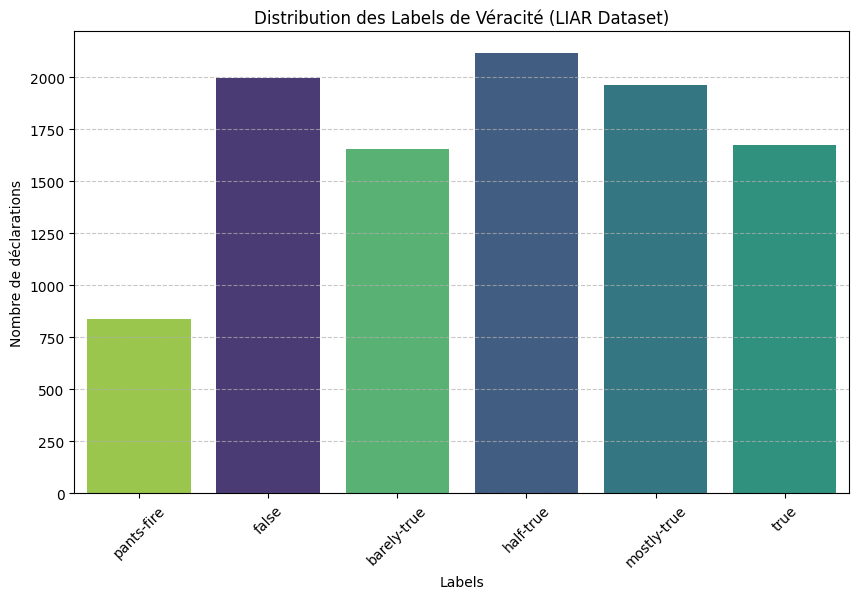

In [5]:
# Aperçu rapide
print(f"Nombre de lignes : {len(df)}")
print(df[['speaker', 'party', 'statement', 'label']].head())
print('\n')
print(df.dtypes)

# Valeurs manquantes
missing_values = df.isnull().sum()
print('\n')
print(f"Nombre de valeurs manquantes : \n{missing_values[missing_values > 0]}")

# Doublons
nb_duplicates = df.duplicated().sum()
print('\n')
print(f"Nombre de lignes en double : {nb_duplicates}")

# Visualisation de la distribution des labels
print('\n')
plt.figure(figsize=(10, 6))
order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
sns.countplot(data=df, x='label', order=order, palette='viridis', hue='label', legend=False)
plt.title('Distribution des Labels de Véracité (LIAR Dataset)')
plt.xlabel('Labels')
plt.ylabel('Nombre de déclarations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Test

Nombre de lignes : 1267


Nombre de valeurs manquantes : 
speaker_job    325
state          262
context         17
dtype: int64


Nombre de lignes en double : 0




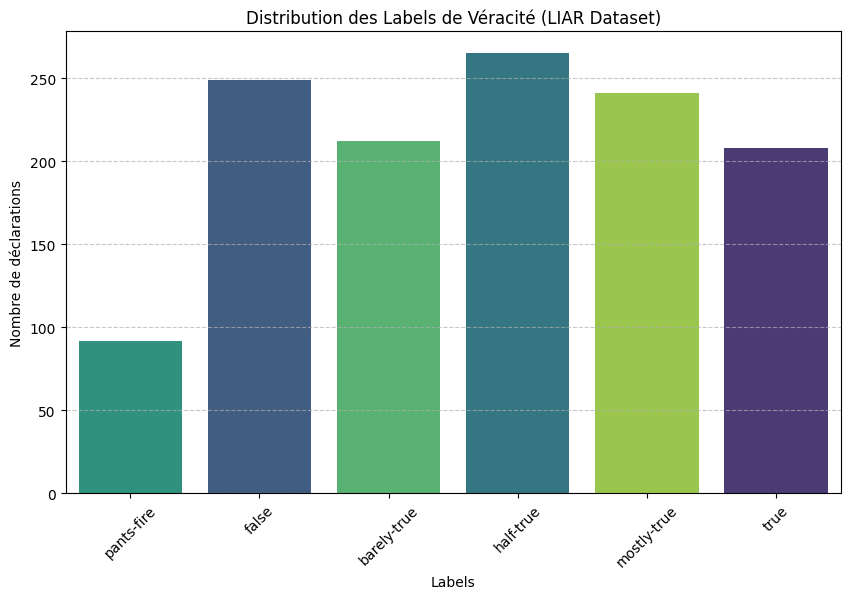

In [6]:
# Aperçu rapide
print(f"Nombre de lignes : {len(df_test)}")

# Valeurs manquantes
missing_values = df_test.isnull().sum()
print('\n')
print(f"Nombre de valeurs manquantes : \n{missing_values[missing_values > 0]}")

# Doublons
nb_duplicates = df_test.duplicated().sum()
print('\n')
print(f"Nombre de lignes en double : {nb_duplicates}")

# Visualisation de la distribution des labels
print('\n')
plt.figure(figsize=(10, 6))
order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
sns.countplot(data=df_test, x='label', order=order, palette='viridis', hue='label', legend=False)
plt.title('Distribution des Labels de Véracité (LIAR Dataset)')
plt.xlabel('Labels')
plt.ylabel('Nombre de déclarations')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preprocessing

### Gestion des valeurs manquantes

Train

In [7]:
# On remplace les NaN par 'unknown'
cols_to_fix = ['subject', 'speaker', 'speaker_job', 'state', 'party', 'context',
               'barely_true', 'false', 'half_true', 'mostly_true',
               'pants_on_fire', 'context']

for col in cols_to_fix:
    df[col] = df[col].fillna('unknown')

# Vérification
print(df[cols_to_fix].isnull().sum())

subject          0
speaker          0
speaker_job      0
state            0
party            0
context          0
barely_true      0
false            0
half_true        0
mostly_true      0
pants_on_fire    0
context          0
dtype: int64


Test

In [8]:
# On remplace les NaN par 'unknown'
cols_to_fix = ['speaker_job', 'state', 'context']

for col in cols_to_fix:
    df_test[col] = df_test[col].fillna('unknown')

# Vérification
print(df_test[cols_to_fix].isnull().sum())

speaker_job    0
state          0
context        0
dtype: int64


### Gestion du déséquilibre des classes (Mappage des Labels)

Train

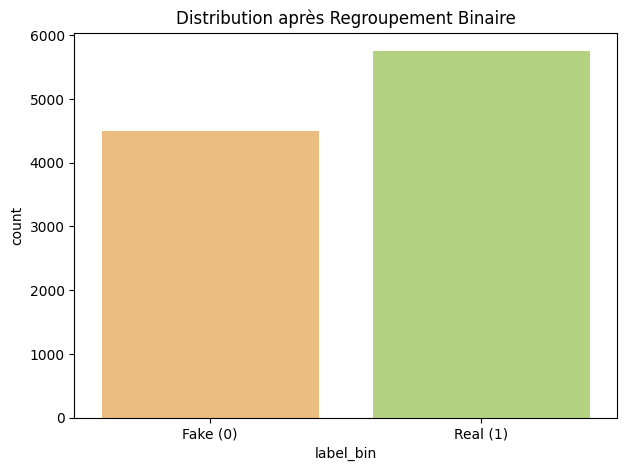

Proportions après regroupement :
label_bin
1    0.561719
0    0.438281
Name: proportion, dtype: float64


In [9]:
# Définition du dictionnaire de correspondance (Mapping)
# On regroupe les catégories de doute/mensonge vs les catégories de vérité
binary_map = {
    'pants-fire': 0,
    'false': 0,
    'barely-true': 0,
    'half-true': 1,
    'mostly-true': 1,
    'true': 1
}

# Création de la nouvelle colonne
df['label_bin'] = df['label'].map(binary_map)

# Vérification de la nouvelle distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label_bin', hue='label_bin', palette='RdYlGn', legend=False)
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.title('Distribution après Regroupement Binaire')
plt.show()

print("Proportions après regroupement :")
print(df['label_bin'].value_counts(normalize=True))

Test

In [10]:
# Application du mapping binaire
df_test['label_bin'] = df_test['label'].map(binary_map)

### Nettoyage et tokenisation

Train

In [11]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Mise en minuscule
    text = text.lower()
    # Suppression de la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenisation
    tokens = word_tokenize(text)
    # Suppression des stopwords
    cleaned_tokens = [w for w in tokens if w not in stop_words]
    return " ".join(cleaned_tokens)

# Application sur le dataframe (colonne 'statement')
df['cleaned_statement'] = df['statement'].apply(clean_text)

print(df[['statement', 'cleaned_statement']].head())

                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   
3  Health care reform legislation is likely to ma...   
4  The economic turnaround started at the end of ...   

                                   cleaned_statement  
0  says annies list political group supports thir...  
1  decline coal start started natural gas took st...  
2  hillary clinton agrees john mccain voting give...  
3  health care reform legislation likely mandate ...  
4               economic turnaround started end term  


Test

In [12]:
df_test['cleaned_statement'] = df_test['statement'].apply(clean_text)

### Feature Engineering

#### TF-IDF

L'étape de vectorisation transforme le texte brut en données numériques exploitables par les modèles de Machine Learning.

1.  **Principe du TF-IDF** : Au lieu de compter simplement l'occurrence des mots, on calcule un score d'importance :
    * **TF (Term Frequency)** : Importance locale (poids élevé si le mot est fréquent dans la phrase).
    * **IDF (Inverse Document Frequency)** : Importance globale (pénalise les mots trop communs comme "the" ou "dit" et valorise les mots rares et discriminants).
2.  **Configuration (`max_features=5000`)** : On ne conserve que les 5 000 mots les plus fréquents pour réduire le bruit, accélérer les calculs et éviter le sur-apprentissage (*overfitting*).
3.  **Méthode `fit_transform`** :
    * **`fit`** : Apprend le vocabulaire et calcule les scores IDF sur le jeu d'entraînement.
    * **`transform`** : Convertit chaque texte en un vecteur de 5 000 dimensions.
4.  **Format (`toarray`)** : Convertit la "matrice creuse" (optimisée pour la mémoire car pleine de zéros) en une "matrice dense" (tableau classique) pour faciliter la manipulation et l'affichage.

In [13]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_statement']).toarray()

print(f"Forme de la matrice TF-IDF : {X_tfidf.shape}")

Forme de la matrice TF-IDF : (10240, 5000)


In [14]:
X_tfidf_test = tfidf.transform(df_test['cleaned_statement']).toarray()

print(f"Train: {X_tfidf.shape}, Test: {X_tfidf_test.shape}")

Train: (10240, 5000), Test: (1267, 5000)


#### Embeddings (Word2Vec / GloVe)

Contrairement au TF-IDF, **Word2Vec** capture les relations sémantiques entre les mots.

1. **Entraînement** : Le modèle apprend le sens des mots en observant leur contexte (mots voisins).
2. **Vectorisation** : Chaque mot est traduit en un vecteur de dimension 100.
3. **Agrégation** : Pour représenter une phrase complète, on calcule la **moyenne des vecteurs** de tous les mots qui la composent.
4. **Avantage** : Cette méthode réduit la dimensionnalité (100 colonnes au lieu de 5000) tout en préservant la proximité de sens entre les termes (ex: "Obama" et "President" seront proches dans l'espace).

In [15]:
# On travaille sur des listes de mots pour Word2Vec
sentences = [row.split() for row in df['cleaned_statement']]
sentences_test = [row.split() for row in df_test['cleaned_statement']]

# Entraînement d'un modèle Word2Vec simple
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Fonction pour obtenir le vecteur moyen d'une phrase
def get_sentence_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([get_sentence_vector(s, w2v_model) for s in sentences])
X_w2v_test = np.array([get_sentence_vector(s, w2v_model) for s in sentences_test])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Pour améliorer la robustesse du modèle face au **Domain Shift**, nous utilisons également des vecteurs pré-entraînés **GloVe**.

* **Méthode** : Chaque phrase est représentée par le vecteur moyen de ses mots constitutifs.
* **Avantage** : Contrairement à Word2Vec entraîné localement, GloVe apporte une connaissance sémantique externe, permettant de mieux traiter des mots peu fréquents dans le dataset LIAR mais communs dans la langue anglaise.

In [20]:
def load_glove_model(file_path):
    print("Chargement du modèle GloVe...")
    glove_index = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            glove_index[word] = coefs
    print(f"Terminé. {len(glove_index)} mots chargés.")
    return glove_index

# Recherche du fichier GloVe
glove_filename = 'glove.6B.100d.txt'

# 1) Tentatives directes
candidate_paths = [
    glove_filename,
    os.path.join(os.getcwd(), glove_filename),
    os.path.join(os.path.expanduser("~"), glove_filename),
]
glove_path = next((p for p in candidate_paths if os.path.exists(p)), None)

# 2) Recherche récursive depuis le dossier courant si introuvable
if glove_path is None:
    for root, _, files in os.walk("."):
        if glove_filename in files:
            glove_path = os.path.join(root, glove_filename)
            break

# 3) Si toujours introuvable, afficher avertissement et utiliser Word2Vec comme fallback
if glove_path is None:
    print("⚠️  Attention: GloVe (glove.6B.100d.txt) introuvable.")
    print("   Assurez-vous que la cellule de téléchargement a été exécutée.")
    print("   Continuons avec Word2Vec à la place...")
    GLOVE_AVAILABLE = False
else:
    print(f"✅ Fichier GloVe trouvé : {glove_path}")
    glove_index = load_glove_model(glove_path)
    GLOVE_AVAILABLE = True

⚠️  Attention: GloVe (glove.6B.100d.txt) introuvable.
   Assurez-vous que la cellule de téléchargement a été exécutée.
   Continuons avec Word2Vec à la place...


In [21]:
def get_sentence_embedding(text, model, vector_size=100):
    # On découpe la phrase nettoyée en mots
    words = text.split()
    # On récupère les vecteurs des mots s'ils existent dans GloVe
    vectors = [model[w] for w in words if w in model]

    if not vectors:
        # Si aucun mot n'est connu, on renvoie un vecteur de zéros
        return np.zeros(vector_size)

    # Moyenne mathématique de la phrase
    return np.mean(vectors, axis=0)

# Création de la matrice X pour le modèle (seulement si GloVe est disponible)
if GLOVE_AVAILABLE:
    X_glove = np.array([get_sentence_embedding(s, glove_index) for s in df['cleaned_statement']])
    print(f"Forme de la matrice GloVe : {X_glove.shape}")
else:
    print("⚠️  GloVe non disponible - création d'une matrice vide")
    X_glove = None

⚠️  GloVe non disponible - création d'une matrice vide


In [22]:
if GLOVE_AVAILABLE:
    X_glove_test = np.array([get_sentence_embedding(s, glove_index) for s in df_test['cleaned_statement']])
else:
    X_glove_test = None

#### Embeddings Contextuels (BERT / RoBERTa)

Nous utilisons ici **DistilBERT**, une version compressée de BERT (95% des performances pour 40% de paramètres en moins).

* **Embeddings Contextuels** : Contrairement à Word2Vec/GloVe, BERT analyse la phrase entière pour définir le sens d'un mot selon son contexte exact.
* **Token [CLS]** : Nous extrayons le vecteur du premier token spécial (`[CLS]`), qui contient une représentation mathématique condensée de toute la déclaration.
* **Dimension** : Le vecteur passe à **768 dimensions**, offrant une richesse d'information bien supérieure aux 100 dimensions des modèles précédents.

Contrairement aux modèles statistiques (TF-IDF) ou aux embeddings statiques (Word2Vec), **BERT** ne nécessite pas (et déconseille) la suppression des *stopwords* ou de la ponctuation.

**Pourquoi ?**
* **Contexte sémantique** : Les mots de liaison et la ponctuation aident BERT à saisir les nuances et les relations de dépendance dans la phrase.
* **Tokenisation native** : BERT utilise son propre tokenizer (**WordPiece**). Lui fournir un texte déjà transformé par NLTK pourrait dégrader ses performances.

Nous utilisons donc ici la colonne brute `statement` pour l'extraction des vecteurs BERT.

Pour transformer nos déclarations en vecteurs contextuels, nous utilisons deux composants clés :
1. **Le Tokenizer (`AutoTokenizer`)** : Il ne se contente pas de couper les mots, il les transforme en "WordPieces" et ajoute des tokens spéciaux comme `[CLS]` (début de phrase) et `[SEP]` (fin).
2. **Le Modèle (`AutoModel`)** : C'est le cœur du transformeur. Il contient 6 couches d'attention qui calculent le poids de chaque mot par rapport aux autres dans la phrase.

In [25]:
# Chargement du tokenizer et du modèle pré-entraîné
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Utiliser le GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Modèle chargé sur : {device}")

def get_bert_embeddings(text):
    # Tokenisation et conversion en tenseurs
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)

    # Passage dans le modèle (sans calcul de gradient pour aller plus vite)
    with torch.no_grad():
        outputs = model(**inputs)

    # Récupération du vecteur du token [CLS]
    # Le token [CLS] est au début de chaque phrase et sert de résumé sémantique global
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return embeddings[0]

# Exemple sur une phrase
# print(get_bert_embeddings("This is a fake news test"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé sur : cpu


In [26]:
tqdm.pandas()

# On applique l'extraction sur notre colonne nettoyée
print("Extraction des vecteurs DistilBERT en cours (cela peut prendre quelques minutes)...")
X_bert = np.array([get_bert_embeddings(s) for s in tqdm(df['statement'])])

print(f"Forme de la matrice BERT : {X_bert.shape}")

Extraction des vecteurs DistilBERT en cours (cela peut prendre quelques minutes)...


 15%|█▌        | 1556/10240 [00:40<03:47, 38.24it/s]


KeyboardInterrupt: 

In [ ]:
X_bert_test = np.array([get_bert_embeddings(s) for s in tqdm(df_test['statement'])])

## Modélisation

L'objectif de cette étape est d'entraîner plusieurs algorithmes de classification pour identifier les signaux faibles du mensonge dans les déclarations politiques.

Nous adoptons une approche comparative en testant trois familles de modèles :
1. **Modèles Linéaires (Logistic Regression)** : Pour établir une base de référence (*Baseline*) simple et interprétable.
2. **Modèles d'Ensemble (XGBoost)** : Pour repérer les combinaisons de mots et les nuances subtiles que les modèles simples ne voient pas.
3. **Deep Learning Contextuel (BERT)** : Pour exploiter la compréhension sémantique profonde des phrases.

Chaque modèle sera évalué non seulement sur sa précision globale (**Accuracy**), mais surtout sur sa capacité à généraliser et sur son **F1-score**, afin de s'assurer que les classes minoritaires (les mensonges les plus graves) ne sont pas ignorées.

In [24]:
# On regroupe les couples (Train, Test) pour chaque méthode
features = {
    'TF-IDF': (X_tfidf, X_tfidf_test),
    'Word2Vec': (X_w2v, X_w2v_test),
}

# Ajouter DistilBERT seulement s'il est disponible
try:
    if 'X_bert' in locals() and X_bert is not None:
        features['DistilBERT'] = (X_bert, X_bert_test)
except NameError:
    pass

# Ajouter GloVe seulement s'il est disponible
if GLOVE_AVAILABLE and X_glove is not None:
    features['GloVe'] = (X_glove, X_glove_test)

print(f"Vecteurs disponibles : {list(features.keys())}")

# Dictionnaire pour stocker les modèles pour SHAP plus tard
trained_models = {}
results = []

Vecteurs disponibles : ['TF-IDF', 'Word2Vec']


In [ ]:
# Définition des cibles
y_train = df['label_bin'].values
y_test = df_test['label_bin'].values

print(f"Taille Train : {len(y_train)} | Taille Test : {len(y_test)}")

In [ ]:
for name, (X_tr, X_te) in features.items():
    print(f"Entraînement en cours pour : {name}")

    # --- Modèle 1 : Logistic Regression ---
    lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr.fit(X_tr, y_train) # On entraîne sur le train
    y_pred_lr = lr.predict(X_te) # On prédit sur le test

    results.append({
        'Vecteur': name,
        'Modèle': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'F1-Score': f1_score(y_test, y_pred_lr)
    })
    trained_models[f"{name}_LR"] = lr

    # --- Modèle 2 : XGBoost ---
    xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb.fit(X_tr, y_train)
    y_pred_xgb = xgb.predict(X_te)

    results.append({
        'Vecteur': name,
        'Modèle': 'XGBoost',
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'F1-Score': f1_score(y_test, y_pred_xgb)
    })
    trained_models[f"{name}_XGB"] = xgb

# Affichage du tableau final
import pandas as pd
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='F1-Score', ascending=False))

### Export / import pour travail collaboratif

In [ ]:
# Sauvegarde des vecteurs d'entraînement et de test
# np.save('X_train_bert.npy', X_bert)
# np.save('X_test_bert.npy', X_bert_test)

# Sauvegarde des labels correspondants
# np.save('y_train.npy', y_train)
# np.save('y_test.npy', y_test)

# print("Vecteurs et labels exportés au format .npy")

In [ ]:
# Sauvegarde du modèle XGBoost
# best_model = trained_models['DistilBERT_XGB']

# best_model.save_model('xgb_distilbert.json')

# print("Modèle XGBoost exporté au format .json")

In [ ]:
# Chargement des données NumPy
X_train = np.load('X_train_bert.npy')
X_test = np.load('X_test_bert.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

# Chargement du modèle XGBoost
loaded_xgb = XGBClassifier()
loaded_xgb.load_model('xgb_distilbert.json')

# Test immédiat
y_pred = loaded_xgb.predict(X_test)

print("Modèle et données chargés avec succès !")

### DistilBERT + XGBoost